In [13]:
import numpy as np

In [14]:
class Perceptron:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.activation_func = self._step_function
        self.weights = None
        self.bias = None

    def _step_function(self, x):
        return np.where(x >= 0, 1, 0)
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.errors_ = []
        for _ in range(self.n_iters):
            error_count = 0
            for idx, x_i in enumerate(X):
                linear_output = np.dot(x_i, self.weights) + self.bias
                y_predicted = self.activation_func(linear_output)
                update = self.lr * (y[idx] - y_predicted)
                self.weights += update * x_i
                self.bias += update
                error_count += int(update != 0.0)
            self.errors_.append(error_count)

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return self.activation_func(linear_output)

In [15]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt



iris = load_iris()
X = iris.data[:100, [2, 3]]  # Solo dos características para visualización
y = iris.target[:100]  


In [16]:
perceptron = Perceptron(learning_rate=0.1, n_iters=10)
perceptron.fit(X, y)

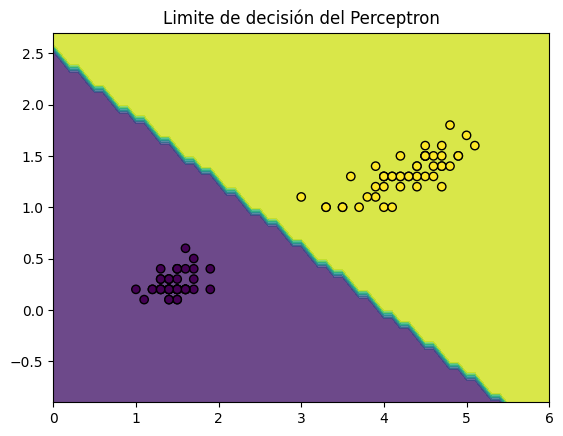

In [17]:
X_min, X_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(X_min, X_max, 0.1),np.arange(y_min, y_max, 0.1))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = perceptron.predict(grid).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o')
plt.title('Limite de decisión del Perceptron')
plt.show()

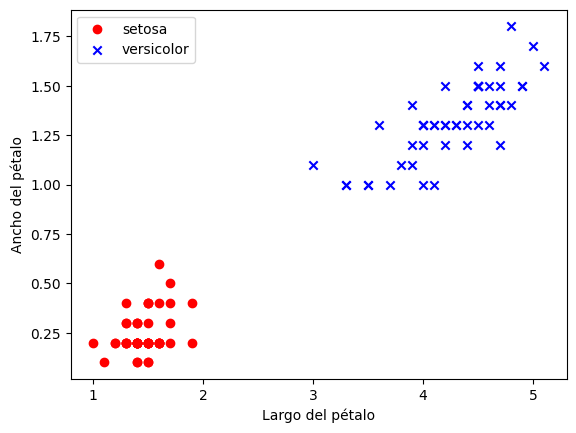

In [30]:
plt.scatter(X[:50, 0], X[:50, 1], color='red', marker='o', label='setosa')
plt.scatter(X[50:, 0], X[50:, 1], color='blue', marker='x', label='versicolor')
plt.xlabel('Largo del pétalo')
plt.ylabel('Ancho del pétalo')
plt.legend(loc='upper left')
plt.show()

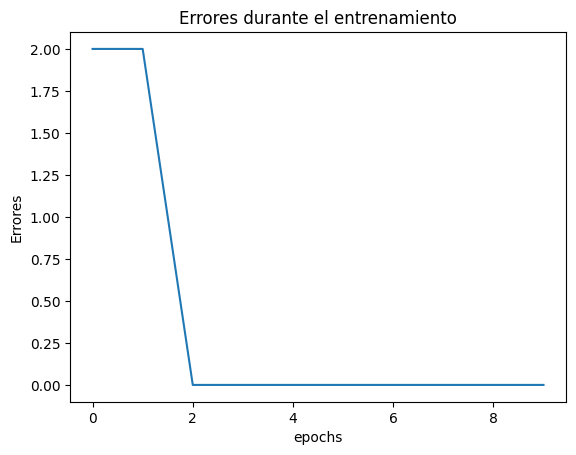

In [18]:
# Errores por epoch
plt.plot(range(len(perceptron.errors_)), perceptron.errors_)
plt.xlabel('epochs')
plt.ylabel('Errores')
plt.title('Errores durante el entrenamiento')
plt.show()

In [23]:
import pandas as pd
import seaborn as sns

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["Target"] = iris.target       

df.head(10)



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


In [22]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


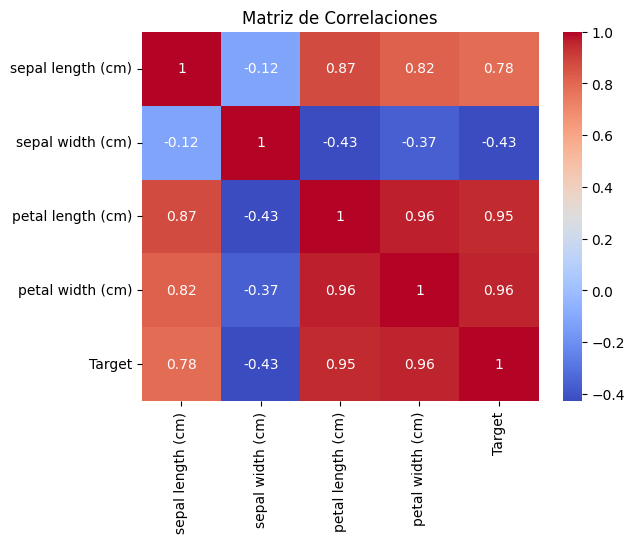

In [24]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm') # Mapa de calor de la matriz de correlación
plt.title('Matriz de Correlaciones')
plt.show()

Coeficiente: 0.4158
Intersección: -0.3631


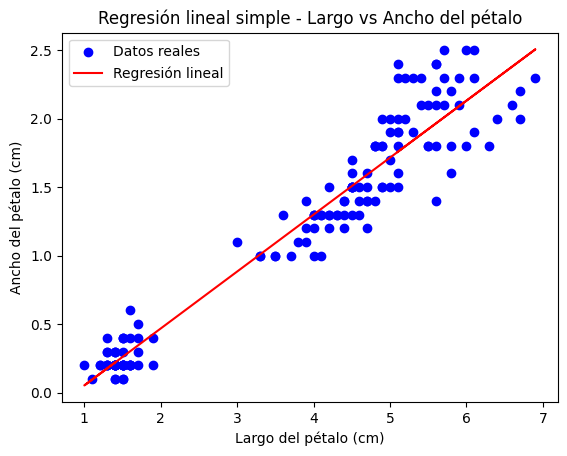

In [31]:
# Regresión Lineal Simple

from sklearn.linear_model import LinearRegression

X_reg = df[['petal length (cm)']]  # variable independiente
y_reg = df['petal width (cm)']     # variable dependiente

model = LinearRegression()
model.fit(X_reg, y_reg)

print(f"Coeficiente: {model.coef_[0]:.4f}")
print(f"Intersección: {model.intercept_:.4f}")

# Predicciones y visualización

plt.scatter(X_reg, y_reg, color='blue', label='Datos reales')
plt.plot(X_reg, model.predict(X_reg), color='red', label='Regresión lineal')
plt.xlabel('Largo del pétalo (cm)')
plt.ylabel('Ancho del pétalo (cm)')
plt.title('Regresión lineal simple - Largo vs Ancho del pétalo')
plt.legend()
plt.show()


In [32]:
# Regresión Multiple

X_multi = df[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)']]
y_multi = df['petal width (cm)']

model_multi = LinearRegression()
model_multi.fit(X_multi, y_multi)

print("Coeficientes:", model_multi.coef_)
print("Intersección:", model_multi.intercept_)
print("R²:", model_multi.score(X_multi, y_multi))


Coeficientes: [-0.20726607  0.22282854  0.52408311]
Intersección: -0.24030738911225824
R²: 0.9378502736046809
